# Case 2 - High Season Decisions at Viador Hotels

**Data-Driven Decisions in Practice · D3 Applications · SS 2026**

Clara Schwarz oversees two mid-sized hotels under the Viador brand â€” a **city** location and a **resort** location. She wants your help refining pricing and capacity decisions for the upcoming high season. Your findings will brief her revenue and operations team: **clarity of communication is key**. Visualisations encouraged. *Pricing strategies should always rely on realised bookings, not mere requests.*

This template provides a **structural scaffold**. Every decision (segmentation thresholds, buffer levels, seasonal rules, adaptive policy) is yours to make and defend.

### Method companions

| Notebook | Focus | Feeds |
|---|---|---|
| [1 · EDA](https://chrisflath.github.io/notebooks/d3ip-case2-rm-1-data.html) | Booking curves, fare-class structure, EDA bridge | Q1, Q3 |
| [2 · Dynamic control](https://chrisflath.github.io/notebooks/d3ip-case2-rm-2-dynamic.html) | Booking strips, revenue surface, S-index | Q4 baseline |
| [3 · Prediction models](https://chrisflath.github.io/notebooks/d3ip-case2-rm-3-prediction.html) | Cancellation classifier, calibration, $q^{\text{eff}}_t$ | Q2, Q4 advanced |

### How to use this file

- Each question is one section. Add as many cells as you need.
- Use the loader in §0; do not re-download per question.
- The final reflection section is **required**.

## §0 · Setup & data loader

The loader below is the same one used in the three companion notebooks. It downloads the public mirror of the Viador booking dataset and adds two helper columns (`booking_date`, `adr_per_adult`).

In [1]:
import numpy as np
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/mpolinowski/hotel-booking-dataset"
    "/refs/heads/master/datasets/hotel_bookings.csv"
)


def load_bookings():
    df = pd.read_csv(DATA_URL)
    df["arrival_date"] = pd.to_datetime(
        df["arrival_date_year"].astype(str)
        + "-"
        + df["arrival_date_month"]
        + "-"
        + df["arrival_date_day_of_month"].astype(str),
        format="%Y-%B-%d",
        errors="coerce",
    )
    df["booking_date"] = df["arrival_date"] - pd.to_timedelta(
        df["lead_time"], unit="D"
    )
    df["adr_per_adult"] = df["adr"] / df["adults"].clip(lower=1)
    return df


bookings = load_bookings()
bookings.shape, bookings["arrival_date"].min(), bookings["arrival_date"].max()

((119390, 35),
 Timestamp('2015-07-01 00:00:00'),
 Timestamp('2017-08-31 00:00:00'))

In [35]:
#shared imports and helper columns
import matplotlib.pyplot as plt
from math import erf, sqrt

bookings["total_nights"] = bookings["stays_in_weekend_nights"] + bookings["stays_in_week_nights"]
realised = bookings[bookings["is_canceled"] == 0].copy()
canceled = bookings[bookings["is_canceled"] == 1].copy()
realised["revenue"] = realised["adr"] * realised["total_nights"]

## §Q1 · Calibrate Advance Sale Policies

Clara offers discounted advance rates but only up to a certain number of bookings. Selling too many in advance turns away spontaneous, higher-paying guests; selling too few leaves occupancy short.

- Using **realised stays**, identify meaningful guest segments for each hotel. *When* do different guest types book? *What* prices do they pay?
- Estimate how many rooms Clara could allocate to advance sales **for each property**. Focus on lead times and, if useful, guest mix.

*Methods reference: companion NB1 §3 (univariate), §4 (per-hotel), §8 (booking curves), §9 (canonical-booking cut tool drives the advance/late split per hotel).*

In [16]:
bookings.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'arrival_date',
       'booking_date', 'adr_per_adult', 'total_nights'],
      dtype='object')

In [31]:
bookings["hotel"].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [41]:
#first: simple time series of bookings per hotel over time, to get a sense of the data and the seasonality - aggregated by week
#dicts in dicts, to have all data in one place for the next steps
bookings_count = {}


bookings_ordered = bookings.sort_values("booking_date")
realised_ordered = realised.sort_values("booking_date")
canceled_ordered = canceled.sort_values("booking_date")

for h in ["City Hotel", "Resort Hotel"]:    
    mask  = bookings_ordered["hotel"] == h
    rmask = realised_ordered["hotel"] == h
    cmask = canceled_ordered["hotel"] == h

    bookings_count[h] = {
        "total": (
            bookings_ordered[mask]
            .set_index("booking_date")
            .resample("W")
            .size()
            .reset_index(name="num_bookings")
        ),
        "realised": (
            realised_ordered[rmask]
            .set_index("booking_date")
            .resample("W")
            .size()
            .reset_index(name="num_bookings")
        ),
        "canceled": (
            canceled_ordered[cmask]
            .set_index("booking_date")
            .resample("W")
            .size()
            .reset_index(name="num_bookings")
        ),
    }

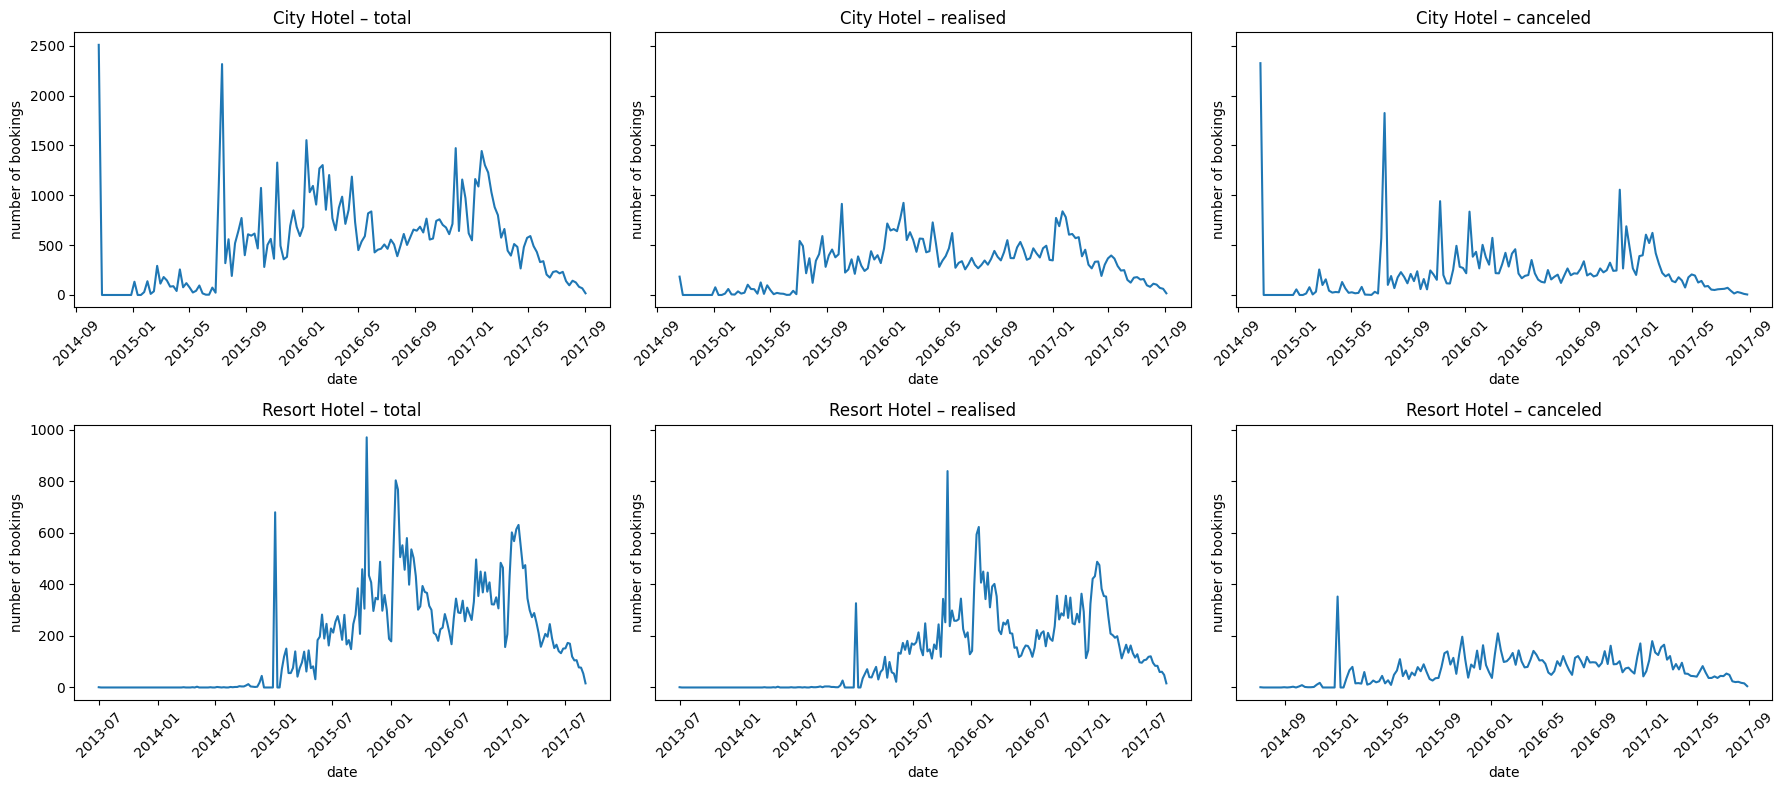

In [42]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8), sharey="row")

hotels = ["City Hotel", "Resort Hotel"]
types  = ["total", "realised", "canceled"]

for i, h in enumerate(hotels):
    for j, t in enumerate(types):
        ax = axes[i, j]
        df = bookings_count[h][t]
        
        ax.plot(df["booking_date"], df["num_bookings"])
        ax.set_title(f"{h} – {t}")
        ax.set_xlabel("date")
        ax.set_ylabel("number of bookings")
        ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Â§Q2 Â· Derive Overbooking Parameters

Clara wants to overbook to mitigate late cancellations and no-shows â€” but walk-aways hurt guest satisfaction and brand image.

- Use historical data to estimate a **robust overbooking buffer** for each hotel. How many extra bookings can Clara accept without incurring frequent walk-aways?
- Make any **trade-offs and assumptions explicit** (walk cost, tolerated walk frequency, independence of cancellations, â€¦).

*Methods reference: companion NB1 Â§7 (cancellation by channel / lead-time), NB3 Â§6 (cancellation model + Brier), Â§8.5 (buffer calculator with tolerated-walk slider).*

In [4]:
# Your Q2 analysis cells go here.

## Â§Q3 Â· Seasonally Update Your Rules

Demand patterns shift across the year. Clara wants Q1's advance sale limits and Q2's overbooking buffers to **adapt to seasonality**.

- Using appropriate aggregates from past years, identify periods of stronger or weaker demand **for each hotel**.
- Provide **updated rules** (per hotel Ã— period) and justify each adjustment with observed patterns.

*Methods reference: companion NB1 Â§6 (temporal patterns), Â§9 with the month picker (re-run Q1's cut per season), NB3 Â§6 (re-fit or re-evaluate cancellation model per season if useful).*

In [5]:
# Your Q3 analysis cells go here.

## Â§Q4 Â· Operate on Live Booking Data

Simulate a realistic decision environment for Viador:

1. **Pick a stay date** and extract its booking strip â€” every booking with any lead time that ultimately stays on that night.
2. Replay it as a **time-ordered stream** of requests (by lead time).
3. Implement an **adaptive control strategy** that:
    - Makes daily decisions based on current capacity and expected high-/low-fare arrivals.
    - **Dynamically updates** protection limits or overbooking thresholds as bookings (and cancellations) arrive.
    - **Integrates at least one trained model** (cancellation probability, ADR forecast, â€¦) to improve decisions.

Report realised revenue, spillage, and walk-aways; compare against the static Q1 + Q2 baseline. A good recommendation is *transparent, robust to noise, and clearly communicated*.

*Methods reference: companion NB2 Â§3 (strip extraction), Â§4a (revenue surface), Â§4b (drill-down), Â§5 (S-index), NB3 Â§6 (calibrated model), Â§8 ($q^{\text{eff}}_t$ trajectory).*

In [6]:
# Your Q4 analysis cells go here.

## Â§R Â· Reflection & methodology

Briefly answer (one short paragraph each):

1. **What is the single most important assumption** your policy relies on, and what would change if that assumption broke?
2. **What did you simplify** that a production deployment could not (cancellation release mechanics, Î» stationarity, channel-mix drift, â€¦)?
3. **What would you do with one more week** of effort?

*Your reflection answers go here.*